In [1]:
%reset -f

from plpm import MainPlots
import numpy as np
import matplotlib.pyplot as plt
from pkg_resources import resource_stream

figures = MainPlots()

In [3]:
# Post-Processing
import pandas as pd
import seaborn as sns

SA_dataVs = np.load(resource_stream('plpm', '../data/SensitivityAnalysis/SA10D_Vs.npz'))
S1Vs = SA_dataVs['S1']
S2Vs = SA_dataVs['S2']
STVs = SA_dataVs['ST']

SA_dataVs = np.load(resource_stream('plpm', '../data/SensitivityAnalysis/SA10D_PlvVlv.npz'))
S1plv = SA_dataVs['S1']
S2plv = SA_dataVs['S2']
STplv = SA_dataVs['ST']

In [4]:
ST_vp = np.vstack((STVs[0:1, :], STplv))
S1_vp = np.vstack((S1Vs[0:1, :], STplv))
S2_vp = np.concatenate((S2Vs[0:1, :, :], S2plv), axis=0)

In [5]:
df_Tvp = pd.DataFrame({'parameters': ['$R_{av}$', '$R_{ao}$', '$C_{ao}$', '$R_{art}$', '$C_{art}$',
                                    '$R_{vc}$', '$C_{vc}$', '$R_{mv}$', '$E_{es}$', '$t_{tr}$',
                                    '$R_{av}$', '$R_{ao}$', '$C_{ao}$', '$R_{art}$', '$C_{art}$',
                                    '$R_{vc}$', '$C_{vc}$', '$R_{mv}$', '$E_{es}$', '$t_{tr}$'],
                     'values': ST_vp.flatten(),
                     'output' :['$V_{lv}$', '$V_{lv}$', '$V_{lv}$', '$V_{lv}$', '$V_{lv}$',
                                '$V_{lv}$', '$V_{lv}$', '$V_{lv}$', '$V_{lv}$', '$V_{lv}$',
                                '$P_{lv}$', '$P_{lv}$', '$P_{lv}$', '$P_{lv}$', '$P_{lv}$',
                                '$P_{lv}$', '$P_{lv}$', '$P_{lv}$', '$P_{lv}$', '$P_{lv}$']}
                   )

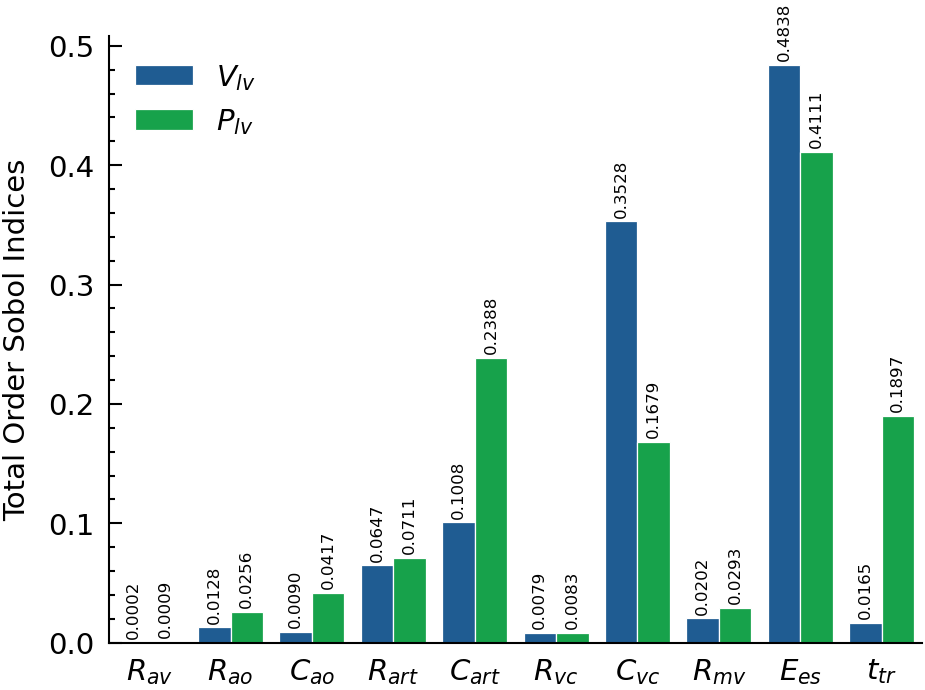

In [6]:
fig, ax = plt.subplots()
sns.barplot(data=df_Tvp, x='parameters', y='values', ax=ax, hue='output',
            edgecolor='white', linewidth=.3)
ax.set_ylabel('Total Order Sobol Indices')
ax.set_xlabel('')
for i in ax.containers:
    ax.bar_label(i, fmt='%.4f', size=4., rotation=90, padding=1.)

ax.tick_params(
    axis='x',      # Apply changes to x axes
    which='both',  # Apply changes to both major and minor ticks
    bottom=False,  # Show or hide ticks on the bottom side
)
ax.legend(title=None)
plt.show(fig)

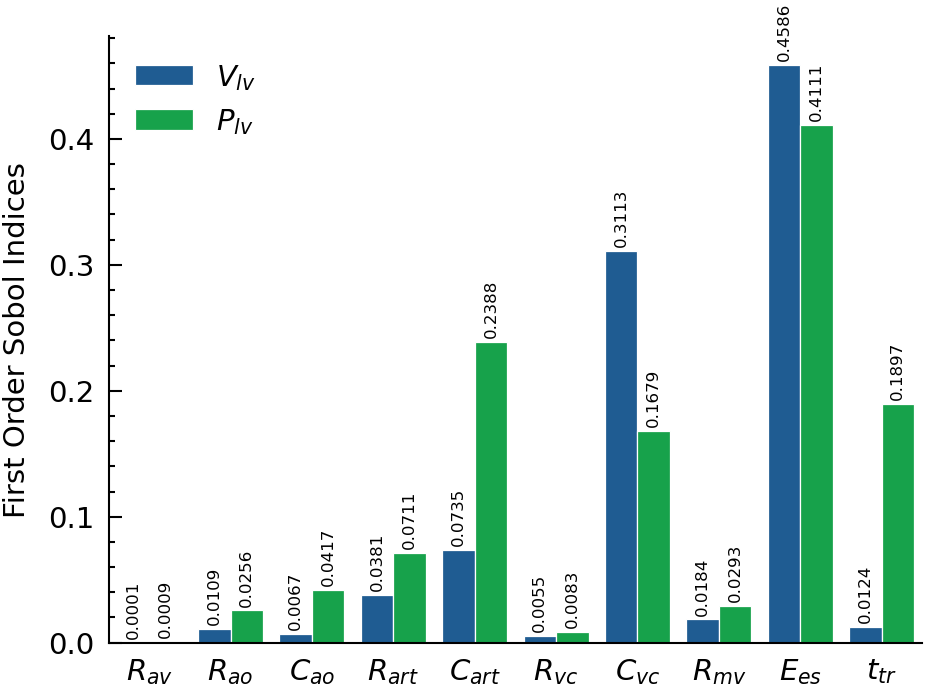

In [7]:
df_1vp = pd.DataFrame({'parameters': ['$R_{av}$', '$R_{ao}$', '$C_{ao}$', '$R_{art}$', '$C_{art}$',
                                    '$R_{vc}$', '$C_{vc}$', '$R_{mv}$', '$E_{es}$', '$t_{tr}$',
                                    '$R_{av}$', '$R_{ao}$', '$C_{ao}$', '$R_{art}$', '$C_{art}$',
                                    '$R_{vc}$', '$C_{vc}$', '$R_{mv}$', '$E_{es}$', '$t_{tr}$'],
                     'values': S1_vp.flatten(),
                     'output' :['$V_{lv}$', '$V_{lv}$', '$V_{lv}$', '$V_{lv}$', '$V_{lv}$',
                                '$V_{lv}$', '$V_{lv}$', '$V_{lv}$', '$V_{lv}$', '$V_{lv}$',
                                '$P_{lv}$', '$P_{lv}$', '$P_{lv}$', '$P_{lv}$', '$P_{lv}$',
                                '$P_{lv}$', '$P_{lv}$', '$P_{lv}$', '$P_{lv}$', '$P_{lv}$']}
                   )

fig, ax = plt.subplots()
sns.barplot(data=df_1vp, x='parameters', y='values', ax=ax, hue='output',
            edgecolor='white', linewidth=.3)
ax.set_ylabel('First Order Sobol Indices')
ax.set_xlabel('')
for i in ax.containers:
    ax.bar_label(i, fmt='%.4f', size=4., rotation=90, padding=1.)

ax.tick_params(
    axis='x',      # Apply changes to x axes
    which='both',  # Apply changes to both major and minor ticks
    bottom=False,  # Show or hide ticks on the bottom side
)
ax.legend(title=None)
plt.show(fig)

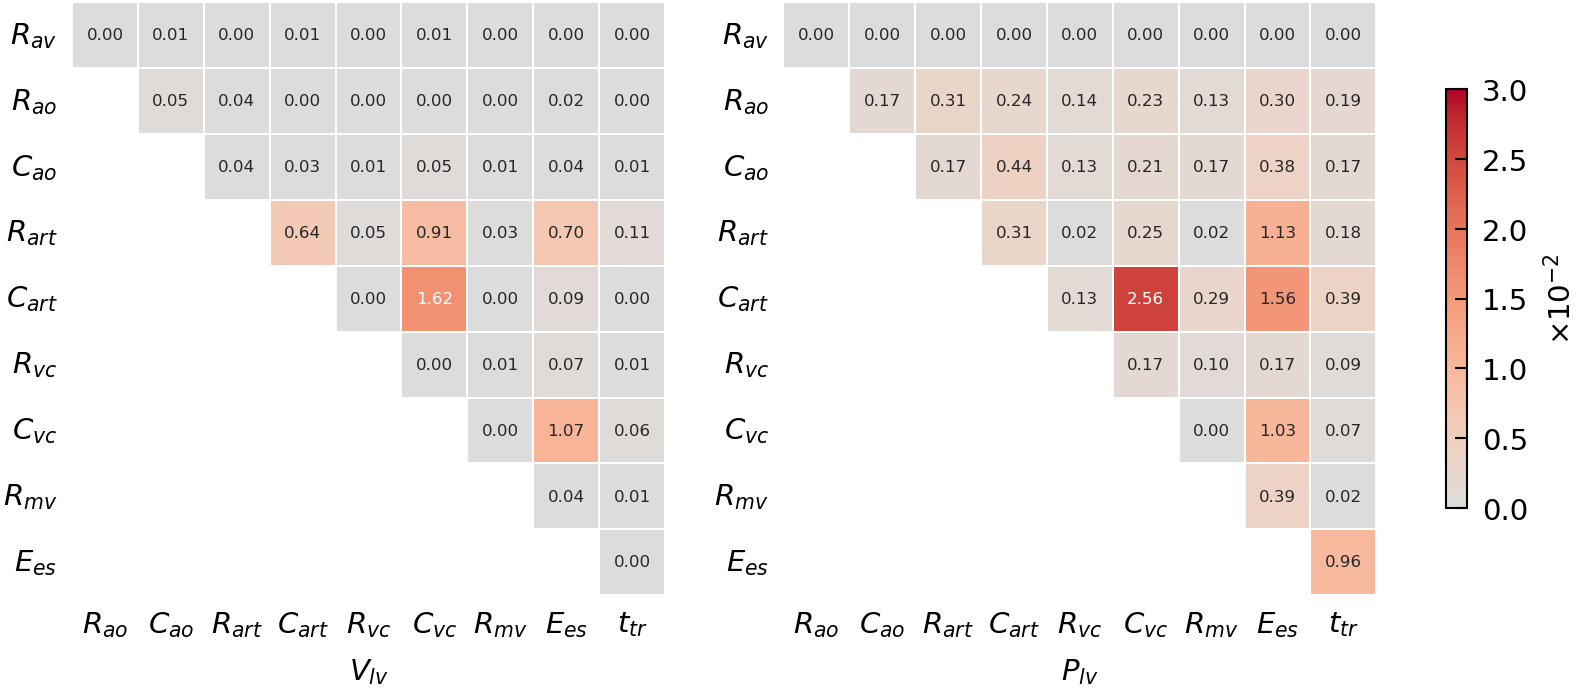

In [8]:
copy_array = np.copy(S2_vp)
copy_array[copy_array < 0] = 0

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(6, 2.65))
cmap=sns.color_palette("coolwarm", as_cmap=True)

ax[0].tick_params(
    axis='both',      # Apply changes to x axes
    which='both',  # Apply changes to both major and minor ticks
    bottom=False,  # Show or hide ticks on the bottom side
    left=False,
)

ax[1].tick_params(
    axis='both',      # Apply changes to x axes
    which='both',  # Apply changes to both major and minor ticks
    bottom=False,  # Show or hide ticks on the bottom side
    left=False,
)


heatmap = sns.heatmap(copy_array[0][:9, 1:10]*100, annot=True, annot_kws={'size': 4},
                      vmin=0., vmax=3., center=0., square=True, linewidths=.1, fmt= '.2f', cmap=cmap, ax=ax[0], cbar=False)
heatmap.set_xticklabels(['$R_{ao}$', '$C_{ao}$', '$R_{art}$', '$C_{art}$',
              '$R_{vc}$', '$C_{vc}$', '$R_{mv}$', '$E_{es}$', '$t_{tr}$'], rotation=0)
heatmap.set_yticklabels(['$R_{av}$', '$R_{ao}$', '$C_{ao}$', '$R_{art}$', '$C_{art}$',
              '$R_{vc}$', '$C_{vc}$', '$R_{mv}$', '$E_{es}$'], rotation=0)
heatmap.set_xlabel('$V_{lv}$')

heatma1 = sns.heatmap(copy_array[1][:9, 1:10]*100, annot=True, annot_kws={'size': 4},
                      vmin=0., vmax=3., center=0., square=True, linewidths=.1, fmt= '.2f', cmap=cmap, ax=ax[1], cbar=False)
heatma1.set_xticklabels(['$R_{ao}$', '$C_{ao}$', '$R_{art}$', '$C_{art}$',
              '$R_{vc}$', '$C_{vc}$', '$R_{mv}$', '$E_{es}$', '$t_{tr}$'], rotation=0)
heatma1.set_yticklabels(['$R_{av}$', '$R_{ao}$', '$C_{ao}$', '$R_{art}$', '$C_{art}$',
              '$R_{vc}$', '$C_{vc}$', '$R_{mv}$', '$E_{es}$'], rotation=0)
heatma1.set_xlabel('$P_{lv}$')

cbar = fig.colorbar(ax[0].collections[0], ax=ax, orientation='vertical', pad=0.05, fraction=0.015, label='$\\times 10^{-2}$')
cbar.minorticks_off()
plt.show(fig)

In [9]:
df_TVs = pd.DataFrame({'parameters': ['$R_{av}$', '$R_{ao}$', '$C_{ao}$', '$R_{art}$', '$C_{art}$',
                                    '$R_{vc}$', '$C_{vc}$', '$R_{mv}$', '$E_{es}$', '$t_{tr}$',
                                    '$R_{av}$', '$R_{ao}$', '$C_{ao}$', '$R_{art}$', '$C_{art}$',
                                    '$R_{vc}$', '$C_{vc}$', '$R_{mv}$', '$E_{es}$', '$t_{tr}$',
                                    '$R_{av}$', '$R_{ao}$', '$C_{ao}$', '$R_{art}$', '$C_{art}$',
                                    '$R_{vc}$', '$C_{vc}$', '$R_{mv}$', '$E_{es}$', '$t_{tr}$',
                                    '$R_{av}$', '$R_{ao}$', '$C_{ao}$', '$R_{art}$', '$C_{art}$',
                                    '$R_{vc}$', '$C_{vc}$', '$R_{mv}$', '$E_{es}$', '$t_{tr}$'],
                     'values': STVs[1:, :].flatten(),
                     'output' :['$V_{ao}$', '$V_{ao}$', '$V_{ao}$', '$V_{ao}$', '$V_{ao}$',
                                '$V_{ao}$', '$V_{ao}$', '$V_{ao}$', '$V_{ao}$', '$V_{ao}$',
                                '$V_{art}$', '$V_{art}$', '$V_{art}$', '$V_{art}$', '$V_{art}$',
                                '$V_{art}$', '$V_{art}$', '$V_{art}$', '$V_{art}$', '$V_{art}$',
                                '$V_{vc}$', '$V_{vc}$', '$V_{vc}$', '$V_{vc}$', '$V_{vc}$',
                                '$V_{vc}$', '$V_{vc}$', '$V_{vc}$', '$V_{vc}$', '$V_{vc}$',
                                '$V_{la}$', '$V_{la}$', '$V_{la}$', '$V_{la}$', '$V_{la}$',
                                '$V_{la}$', '$V_{la}$', '$V_{la}$', '$V_{la}$', '$V_{la}$']}
                   )

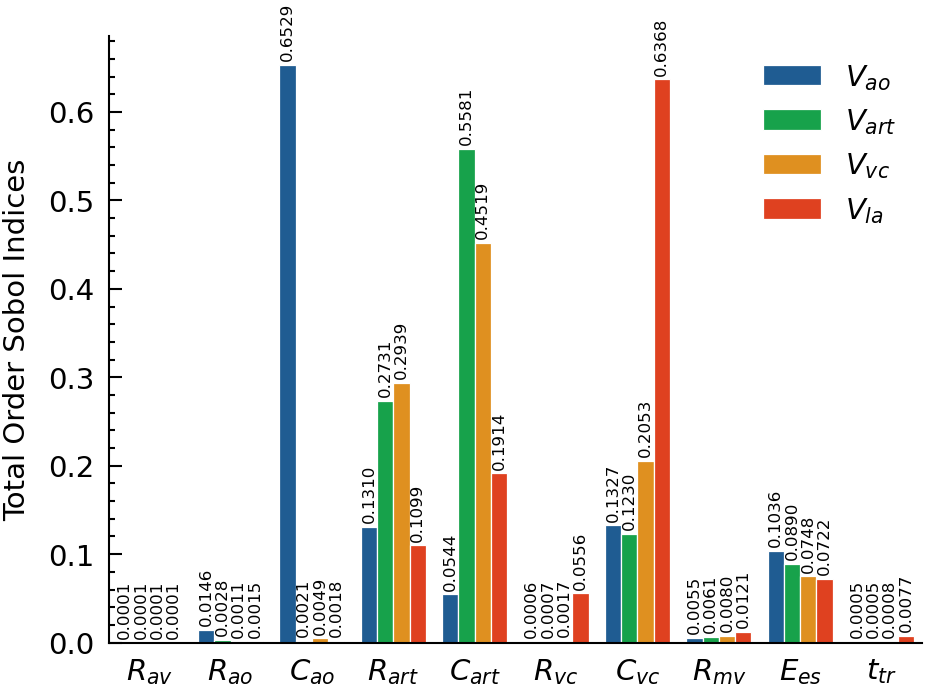

In [10]:
fig, ax = plt.subplots()
sns.barplot(data=df_TVs, x='parameters', y='values', ax=ax, hue='output',
            edgecolor='white', linewidth=.3)
ax.set_ylabel('Total Order Sobol Indices')
ax.set_xlabel('')
for i in ax.containers:
    ax.bar_label(i, fmt='%.4f', size=4., rotation=90, padding=1.)

ax.tick_params(
    axis='x',      # Apply changes to x axes
    which='both',  # Apply changes to both major and minor ticks
    bottom=False,  # Show or hide ticks on the bottom side
)
ax.legend(title=None)
plt.show(fig)

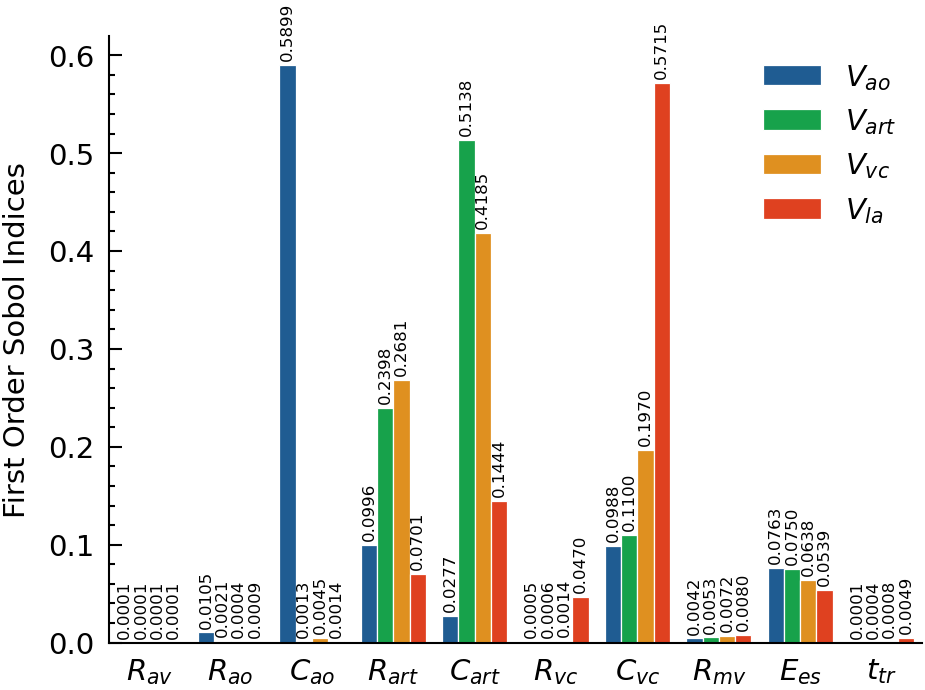

In [11]:
df_1Vs = pd.DataFrame({'parameters': ['$R_{av}$', '$R_{ao}$', '$C_{ao}$', '$R_{art}$', '$C_{art}$',
                                    '$R_{vc}$', '$C_{vc}$', '$R_{mv}$', '$E_{es}$', '$t_{tr}$',
                                    '$R_{av}$', '$R_{ao}$', '$C_{ao}$', '$R_{art}$', '$C_{art}$',
                                    '$R_{vc}$', '$C_{vc}$', '$R_{mv}$', '$E_{es}$', '$t_{tr}$',
                                    '$R_{av}$', '$R_{ao}$', '$C_{ao}$', '$R_{art}$', '$C_{art}$',
                                    '$R_{vc}$', '$C_{vc}$', '$R_{mv}$', '$E_{es}$', '$t_{tr}$',
                                    '$R_{av}$', '$R_{ao}$', '$C_{ao}$', '$R_{art}$', '$C_{art}$',
                                    '$R_{vc}$', '$C_{vc}$', '$R_{mv}$', '$E_{es}$', '$t_{tr}$'],
                     'values': S1Vs[1:, :].flatten(),
                     'output' :['$V_{ao}$', '$V_{ao}$', '$V_{ao}$', '$V_{ao}$', '$V_{ao}$',
                                '$V_{ao}$', '$V_{ao}$', '$V_{ao}$', '$V_{ao}$', '$V_{ao}$',
                                '$V_{art}$', '$V_{art}$', '$V_{art}$', '$V_{art}$', '$V_{art}$',
                                '$V_{art}$', '$V_{art}$', '$V_{art}$', '$V_{art}$', '$V_{art}$',
                                '$V_{vc}$', '$V_{vc}$', '$V_{vc}$', '$V_{vc}$', '$V_{vc}$',
                                '$V_{vc}$', '$V_{vc}$', '$V_{vc}$', '$V_{vc}$', '$V_{vc}$',
                                '$V_{la}$', '$V_{la}$', '$V_{la}$', '$V_{la}$', '$V_{la}$',
                                '$V_{la}$', '$V_{la}$', '$V_{la}$', '$V_{la}$', '$V_{la}$']}
                   )

fig, ax = plt.subplots()
sns.barplot(data=df_1Vs, x='parameters', y='values', ax=ax, hue='output',
            edgecolor='white', linewidth=.3)
ax.set_ylabel('First Order Sobol Indices')
ax.set_xlabel('')
for i in ax.containers:
    ax.bar_label(i, fmt='%.4f', size=4., rotation=90, padding=1.)

ax.tick_params(
    axis='x',      # Apply changes to x axes
    which='both',  # Apply changes to both major and minor ticks
    bottom=False,  # Show or hide ticks on the bottom side
)
ax.legend(title=None)
plt.show(fig)

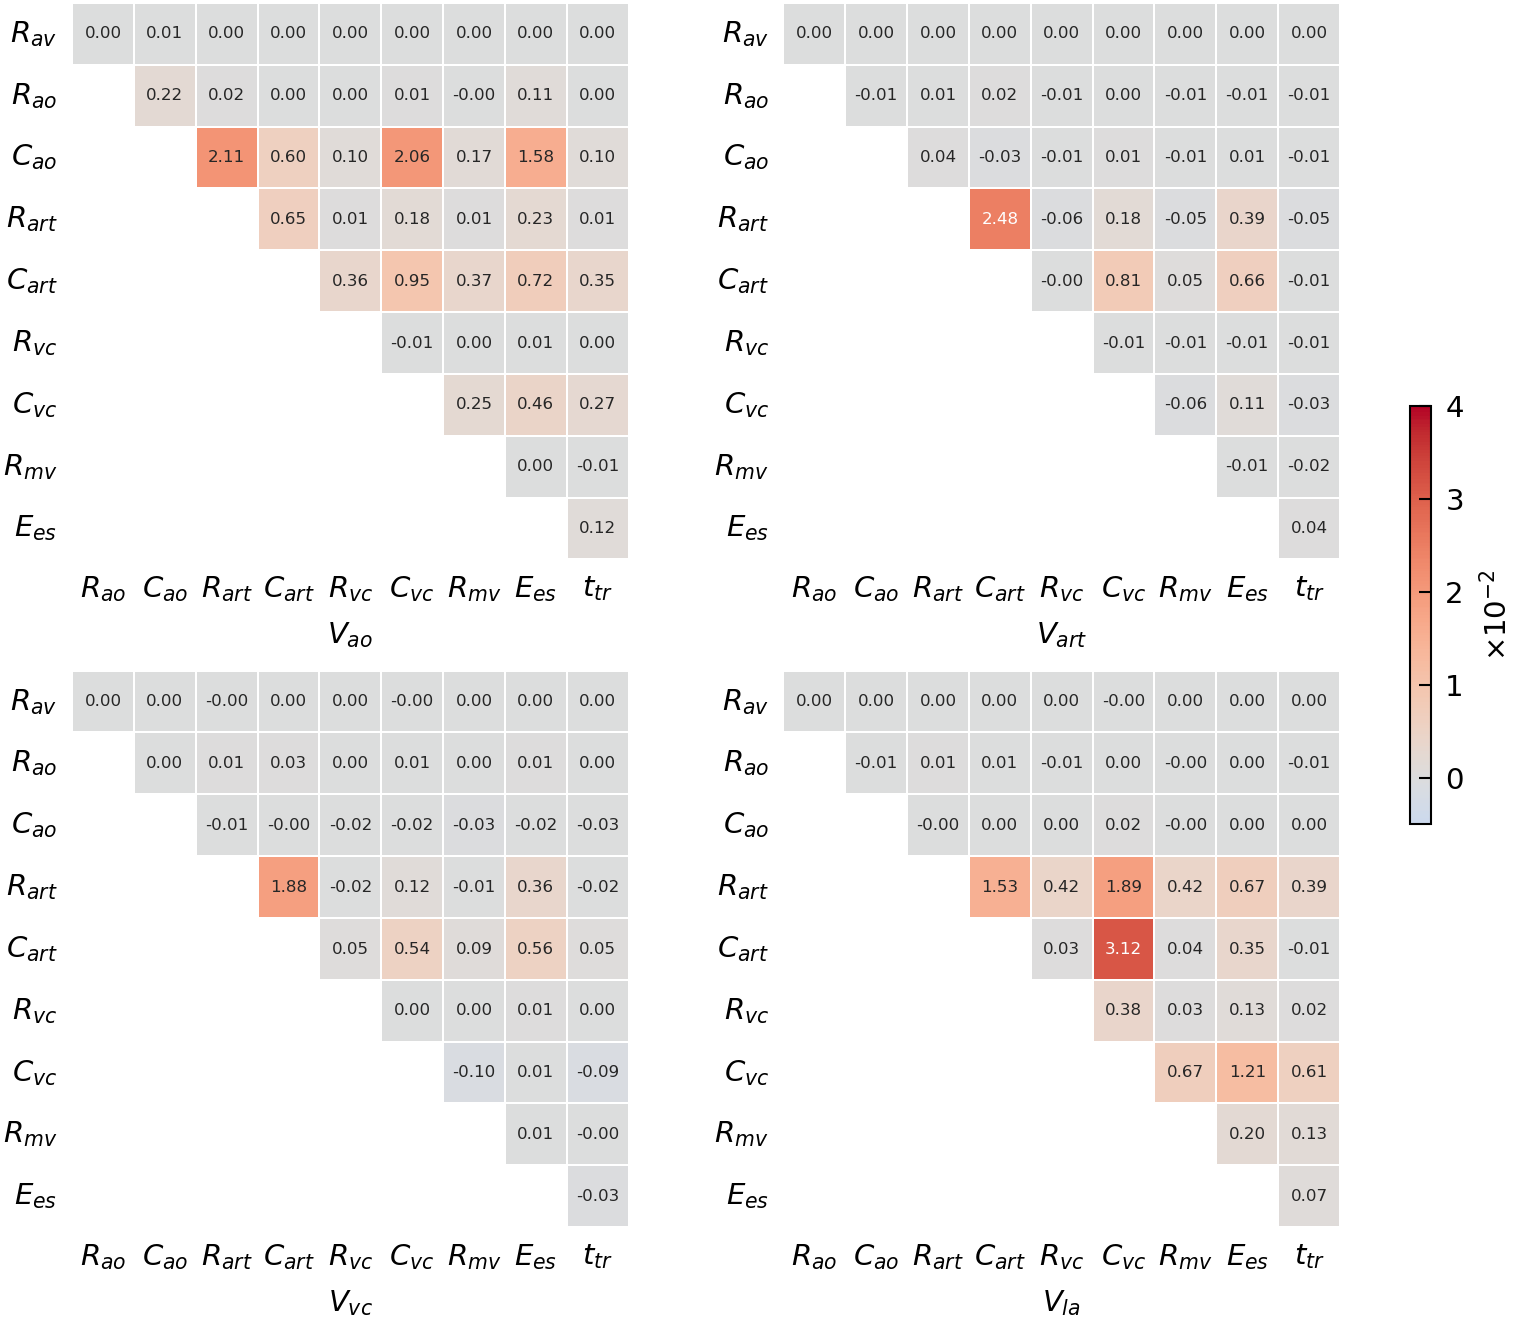

In [12]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(6, 5.3))
cmap=sns.color_palette("coolwarm", as_cmap=True)

ax[0, 0].tick_params(
    axis='both',      # Apply changes to x axes
    which='both',  # Apply changes to both major and minor ticks
    bottom=False,  # Show or hide ticks on the bottom side
    left=False,
)

ax[0, 1].tick_params(
    axis='both',      # Apply changes to x axes
    which='both',  # Apply changes to both major and minor ticks
    bottom=False,  # Show or hide ticks on the bottom side
    left=False,
)

ax[1, 0].tick_params(
    axis='both',      # Apply changes to x axes
    which='both',  # Apply changes to both major and minor ticks
    bottom=False,  # Show or hide ticks on the bottom side
    left=False,
)

ax[1, 1].tick_params(
    axis='both',      # Apply changes to x axes
    which='both',  # Apply changes to both major and minor ticks
    bottom=False,  # Show or hide ticks on the bottom side
    left=False,
)


heatmap = sns.heatmap(S2Vs[1][:9, 1:10]*100, annot=True, annot_kws={'size': 4},
                      vmin=-.5, vmax=4., center=0., square=True, linewidths=.1, fmt= '.2f', cmap=cmap, ax=ax[0, 0], cbar=False)
heatmap.set_xticklabels(['$R_{ao}$', '$C_{ao}$', '$R_{art}$', '$C_{art}$',
              '$R_{vc}$', '$C_{vc}$', '$R_{mv}$', '$E_{es}$', '$t_{tr}$'], rotation=0)
heatmap.set_yticklabels(['$R_{av}$', '$R_{ao}$', '$C_{ao}$', '$R_{art}$', '$C_{art}$',
              '$R_{vc}$', '$C_{vc}$', '$R_{mv}$', '$E_{es}$'], rotation=0)
heatmap.set_xlabel('$V_{ao}$')

heatma1 = sns.heatmap(S2Vs[2][:9, 1:10]*100, annot=True, annot_kws={'size': 4},
                      vmin=-.5, vmax=4., center=0., square=True, linewidths=.1, fmt= '.2f', cmap=cmap, ax=ax[0, 1], cbar=False)
heatma1.set_xticklabels(['$R_{ao}$', '$C_{ao}$', '$R_{art}$', '$C_{art}$',
              '$R_{vc}$', '$C_{vc}$', '$R_{mv}$', '$E_{es}$', '$t_{tr}$'], rotation=0)
heatma1.set_yticklabels(['$R_{av}$', '$R_{ao}$', '$C_{ao}$', '$R_{art}$', '$C_{art}$',
              '$R_{vc}$', '$C_{vc}$', '$R_{mv}$', '$E_{es}$'], rotation=0)
heatma1.set_xlabel('$V_{art}$')

heatma2 = sns.heatmap(S2Vs[3][:9, 1:10]*100, annot=True, annot_kws={'size': 4},
                      vmin=-.5, vmax=4., center=0., square=True, linewidths=.1, fmt= '.2f', cmap=cmap, ax=ax[1, 0], cbar=False)
heatma2.set_xticklabels(['$R_{ao}$', '$C_{ao}$', '$R_{art}$', '$C_{art}$',
              '$R_{vc}$', '$C_{vc}$', '$R_{mv}$', '$E_{es}$', '$t_{tr}$'], rotation=0)
heatma2.set_yticklabels(['$R_{av}$', '$R_{ao}$', '$C_{ao}$', '$R_{art}$', '$C_{art}$',
              '$R_{vc}$', '$C_{vc}$', '$R_{mv}$', '$E_{es}$'], rotation=0)
heatma2.set_xlabel('$V_{vc}$')

heatma3 = sns.heatmap(S2Vs[4][:9, 1:10]*100, annot=True, annot_kws={'size': 4},
                      vmin=-.5, vmax=4., center=0., square=True, linewidths=.1, fmt= '.2f', cmap=cmap, ax=ax[1, 1], cbar=False)
heatma3.set_xticklabels(['$R_{ao}$', '$C_{ao}$', '$R_{art}$', '$C_{art}$',
              '$R_{vc}$', '$C_{vc}$', '$R_{mv}$', '$E_{es}$', '$t_{tr}$'], rotation=0)
heatma3.set_yticklabels(['$R_{av}$', '$R_{ao}$', '$C_{ao}$', '$R_{art}$', '$C_{art}$',
              '$R_{vc}$', '$C_{vc}$', '$R_{mv}$', '$E_{es}$'], rotation=0)
heatma3.set_xlabel('$V_{la}$')
cbar = fig.colorbar(ax[1, 1].collections[0], ax=ax, orientation='vertical', pad=0.05, fraction=0.015, label='$\\times 10^{-2}$')
cbar.minorticks_off()
plt.show(fig)